# Notebook 7 - Supply Constraints and Scarcity

The first phase of this project focused on exploratory analysis and served as an introduction to Alberta electricity market fundamentals. Those notebooks have since been archived following the construction of a new master dataset containing improved system-level variables, including:

- generation availability
- generation outages
- fuel-specific outages
- fuel-specific available capacity
- intertie flows
- operational system-state variables

This notebook marks the beginning of a second phase of analysis. Some earlier findings will be revisited using the improved dataset, while new questions will be explored using the additional operational data now available.

The primary objective is to better understand the physical and operational drivers of scarcity. Particular attention is given to generation availability, outages, imports, capacity margins, renewable output, and system tightness.

Developing a more robust understanding of these relationships provides a foundation for future forecasting, regime analysis, and market applications.

## Data Loading and Feature Construction

load the master dataset and construct the derived features used throughout the analysis.

In [92]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score

from load_data import load_master_data
from features import build_features

df = load_master_data()
df = build_features(df)

# sanity check — verify timestamp alignment and merge integrity
print("Timezone:", df['timestamp'].dt.tz)
print("Shape:", df.shape)
print("\nNull rates on core features:")
print(df[['net_load', 'renewable_share', 'gen_wind', 'scarcity_event']].isna().mean())
print("\nFirst few rows of key columns:")
print(df[['timestamp', 'net_load', 'gen_wind', 'scarcity_event']].head(10))


print(df.shape)
df.head()

Timezone: UTC
Shape: (48929, 193)

Null rates on core features:
net_load           0.0
renewable_share    0.0
gen_wind           0.0
scarcity_event     0.0
dtype: float64

First few rows of key columns:
                  timestamp     net_load    gen_wind  scarcity_event
0 2020-01-01 07:00:00+00:00  8937.537783  529.462217               0
1 2020-01-01 08:00:00+00:00  8891.302367  469.658333               0
2 2020-01-01 09:00:00+00:00  8887.988274  397.419726               0
3 2020-01-01 10:00:00+00:00  8810.919480  396.516520               0
4 2020-01-01 11:00:00+00:00  8825.861889  366.638111               0
5 2020-01-01 12:00:00+00:00  8927.713919  293.306081               0
6 2020-01-01 13:00:00+00:00  9108.508789  229.503211               0
7 2020-01-01 14:00:00+00:00  9378.563540  133.272459               0
8 2020-01-01 15:00:00+00:00  9517.187415  129.820585               0
9 2020-01-01 16:00:00+00:00  9558.436880  186.443120               0
(48929, 193)


,timestamp,aeco__aeco_price_cad_gj,gen__gen_coal_maximum_capacity,gen__gen_cogeneration_maximum_capacity,gen__gen_combined_cycle_maximum_capacity,gen__gen_dual_fuel_maximum_capacity,gen__gen_gas_fired_steam_maximum_capacity,gen__gen_hydro_maximum_capacity,gen__gen_other_maximum_capacity,gen__gen_simple_cycle_maximum_capacity,...,ramp_x_low_reserve,wind_x_netload,renewable_x_netload,imports_x_netload,scarcity_event,scarcity_t_plus_1,scarcity_t_plus_3,scarcity_t_plus_6,scarcity_t_plus_12,scarcity_t_plus_24
0,2020-01-01 07:00:00+00:00,2.06,5034.0,5093.0,1790.0,540.0,NaN,894.0,381.0,855.0,...,NaN,4.732089e+06,1004.165383,7.150030e+05,0,0.0,0.0,0.0,0.0,0.0
1,2020-01-01 08:00:00+00:00,2.06,5034.0,5093.0,1790.0,540.0,NaN,894.0,381.0,855.0,...,27.631258,4.175874e+06,849.867531,1.111413e+06,0,0.0,0.0,0.0,0.0,0.0
2,2020-01-01 09:00:00+00:00,2.06,5034.0,5093.0,1790.0,540.0,NaN,894.0,381.0,855.0,...,1.885407,3.532262e+06,756.032776,1.110999e+06,0,0.0,0.0,0.0,0.0,0.0
3,2020-01-01 10:00:00+00:00,2.06,5034.0,5093.0,1790.0,540.0,NaN,894.0,381.0,855.0,...,43.933103,3.493675e+06,704.636180,1.101365e+06,0,0.0,0.0,0.0,0.0,0.0
4,2020-01-01 11:00:00+00:00,2.06,5034.0,5093.0,1790.0,540.0,NaN,894.0,381.0,855.0,...,8.422340,3.235897e+06,731.768245,1.103233e+06,0,0.0,0.0,0.0,0.0,0.0


In [93]:
# compare AUC on core features against archived notebook values
# net_load was 0.83, renewable_share was 0.79 in earlier notebooks
# if materially lower here, investigate merge or timestamp issue
check_features = ['net_load', 'renewable_share', 'gen_wind']
print("Core feature AUC check:")
for f in check_features:
    result = feature_auc(df, f)
    print(f"  {f}: {result['auc']:.3f}")

Core feature AUC check:
  net_load: 0.780
  renewable_share: 0.715
  gen_wind: 0.688


## Section 1

### Individual Feature Validation

Objective: 
Evaluate the ability of individual variables to distinguish scarcity hours from normal hours. 

Method: 
For each feature, calculate ROC AUC against the scarcity_event label. 

Interpretation: 
- AUC = 0.50 → no separation
- AUC ≈ 0.60 → weak signal
- AUC ≈ 0.70 → useful signal
- AUC ≥ 0.80 → strong signal

This provides a simple ranking of which operational variables contain the most scarcity information before combining them into more complex models.

In [94]:
# candidate explanatory variables to test individually
# each feature will receive its own ROC AUC score
candidate_features = [
    'net_load',
    'renewable_share',
    'gen_wind',
    'outage_total',
    'outages__outage_combined_cycle',
    'outages__outage_cogeneration',
    'outages__outage_simple_cycle',
    'gen__gen_combined_cycle_system_available',
    'gen__gen_cogeneration_system_available',
    'gen__gen_simple_cycle_system_available',
    'total_imports',
    'net_imports',
    'reserve_proxy_pct'
]

In [95]:
# identify any variables that are missing from the dataframe
# prevents analysis from failing later due to misspelled or absent columns
missing_features = []

for col in candidate_features:
    if col not in df.columns:
        missing_features.append(col)

In [96]:
# helper function for single feature AUC analysis
def feature_auc(df, feature, target='scarcity_event'):

    # df with a single feature and target, dropping rows with missing values
    sample = df[[feature, target]].dropna()

    # holds target outcomes and feature values in separate lists
    y_true = sample[target]
    y_score = sample[feature]

    # passes the two lists through the roc_auc_score feature imported from sklearn
    auc = roc_auc_score(y_true, y_score)

    # just making output easier to read
    if auc < 0.5: 
        auc = 1 - auc
        direction = 'negative'
    else: 
        direction = 'positive'
    
    # return a dictionary (key: value pairs)
    return {
        'feature': feature, 
        'auc': auc, 
        'direction': direction,
        'n_obs': len(sample),
    }

In [97]:
# empty list for results
auc_results = []

# loop through candidate features list
for feature in candidate_features:
    # add the returned dictioanry result from the helper function above to the empty list
    auc_results.append(feature_auc(df, feature))

# convert the new list of dictionaries to a pandas dataframe, sort features from highest impact to lowest
auc_df = (
    pd.DataFrame(auc_results).sort_values('auc', ascending=False).reset_index(drop=True)
)

auc_df

,feature,auc,direction,n_obs
0,net_load,0.780158,positive,48929
1,renewable_share,0.714912,negative,48929
2,gen_wind,0.688213,negative,48929
3,total_imports,0.680161,positive,48929
4,net_imports,0.678968,positive,48929
5,reserve_proxy_pct,0.648838,negative,48929
6,outages__outage_simple_cycle,0.636720,positive,48919
7,gen__gen_simple_cycle_system_available,0.600411,negative,48929
8,gen__gen_combined_cycle_system_available,0.555946,negative,48929
9,outage_total,0.548064,positive,48919


In [98]:
# add an interpretation band for easier reading
def auc_band(auc):
    if auc >= 0.80: 
        return 'strong'
    elif auc >= 0.70:
        return 'useful'
    elif auc >= 0.60:
        return 'weak/moderate'
    else: 
        return 'weak'

# create new dataframe column with the auc_band applied
auc_df['signal_strength'] = auc_df['auc'].apply(auc_band)

auc_df

,feature,auc,direction,n_obs,signal_strength
0,net_load,0.780158,positive,48929,useful
1,renewable_share,0.714912,negative,48929,useful
2,gen_wind,0.688213,negative,48929,weak/moderate
3,total_imports,0.680161,positive,48929,weak/moderate
4,net_imports,0.678968,positive,48929,weak/moderate
5,reserve_proxy_pct,0.648838,negative,48929,weak/moderate
6,outages__outage_simple_cycle,0.636720,positive,48919,weak/moderate
7,gen__gen_simple_cycle_system_available,0.600411,negative,48929,weak/moderate
8,gen__gen_combined_cycle_system_available,0.555946,negative,48929,weak
9,outage_total,0.548064,positive,48919,weak


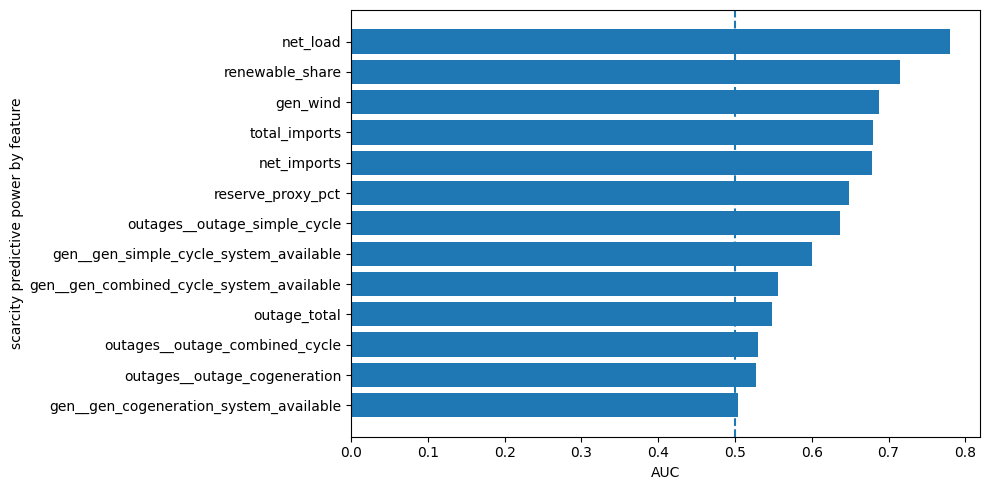

In [99]:
plt.figure(figsize = (10,5))

plot_df = auc_df.sort_values('auc')

plt.barh(
    plot_df['feature'],
    plot_df['auc']
)
 
plt.axvline(
    x = 0.5,
    linestyle = '--'
)

plt.xlabel('AUC')
plt.ylabel('scarcity predictive power by feature')

plt.tight_layout()
plt.show()

#### Observations:

##### Net load remains the dominant scarcity variable.

Net load produced the highest individual AUC score (0.78), outperforming every outage, availability import, and reserve-related variable tested. 

This is an import validation result because it survives a major dataset rebuild. The earlier notebooks reached the same conclusion using a less mature dataset and a different feature engineering pipeline. Despite significant cahnges to the underlying data, the relationship remains intact. 

This suggests that scarcity in Alberta is fundamentally a capacity-to-demand problem. When net load rises, the system requires more dispatchable generation and becomes increasingly vulnerable to scarcity pricing. 

##### Renewable contribution matters more than any individual renewable source

Renewable share was the second strongest feature (AUC = 0.71), outperforming wind gerneation alone. 

This suggests that the market responds more strongly to the aggregate contribution of reneable generation than to wind specifically. From a system perspective, a megawatt of renewable production reduces the need for themrmal generation regardless of whether it comes from wind, solar, or hydro. 

The result implies that overall renewable penetration may be a more useful operational metric than focusing on individual renewable technologies in isolation. 

##### Imports contain meaningful scarcity information

Both total imports and net imports produced AUC values near 0.68, making them amoung the stronger operational variables tested. 

This result is intuitive. Alberta tends to import power when internal supply conditions become tighter. Imports therefore appear to act as a signal of system stress. 

However, the usefulness of imports for forecasting remain unclear. Imports may be responding to developing scarcity conditions rather than predicting them. This distinction becomes important in later forecasting notebooks and should be tested using lagged variables. 

##### Reserve proxy remained weak

The reserve proxy feature produced only moderate explanatory power. 

This likely reflects limitations in the construction of the metric itself. The current proxy estimates system surplus as:

available generation + net imports - demand

While directionally reasonable, this is not equivalent to AESO operating reserves or actual dispatchable reserve margin. 

The result auggests that future work should focus on developing more physically meaningful capacity margin and reserve measures rather than relying on a simple surplus estimate. 

##### Simple-cycle outages appear more informative than other outage categories

Amoung outage variables, simple-cycle outages produced the strongest signal. 

Although the overall predictive power of outage features was modest, this result is operationally plausible. Simple-cycle gas units often serve as peaking resources and become most valuable during periods of system stress. Losing peaking capacity may therefore have a lrager impact on scarcity risk than losing an equivalent amoung of capacity from other technologies.

This finding warrants further investigation but provides an early indication that not all outages contribute equally to scarcity risk. 

##### Aggregate outage measures contain little scarcity information

Total outages produced only weak explanatory power. 

This suggests that treating all outages as equivalent may obscure important operational differences between technologies. Large outage volumes do not necessarily create scarcity if the affected resources are non-critical during the period in question. 

The result reinforces a recurring theme in power markets: system conditions are often driven more by the quality and flexbility of available capacity than by raw outage totals. 

##### Availability along is less important than availability relative to demand

Fuel-specific availability variables generally produced weaker AUC values than expected. 

This suggests that scarcity is not driven by available capacity in isolation. Instead, what matters is the relationship between available capacity and system demand. 

Future feature engineering should therefore focus on relative measures such as: 
- thermal availability as a percentage of load
- dispatchable capacity margin
- available capacity minus net load
- thermal reserve margin

These metrics better reflect the operational balance between supply and demand and are likely to contain stronger scarcity information than absolute availability values alone. 



### Incremental Drivers Beyond Net Load

Objective: 

Identify which operational variables distinguish scarcity hours from non-scarcity hours when net load is already elevated. 

Method: Restrict the analysis to the highest 20% of net load hours and compare average system conditions between scarcity and non-scarcity observations. 

Variables tested include:
- renewable share
- wind generation
- imports
- reserve conditions
- outages

Interpretation: 

If a variable differs materially betweeen scarcity and non-scarcity hours despite similar net load conditions, it may provide information beyond what is already captured by net load itself.

This helps identify secondary drivers of scarcity and highlights which variables contribute incremental explanatory power once demand pressure is already high.

In [103]:
# define high net load in the top 20th percentile
high_netload = (
    df['net_load'] > df['net_load'].quantile(0.8)
)

high_df = df[high_netload]

In [104]:
# define scarcity hours and non scarcity hours
scarcity = high_df[high_df['scarcity_event'] == 1]
normal = high_df[high_df['scarcity_event'] == 0]

# define major feature columns
compare_cols = [
    'renewable_share',
    'gen_wind',
    'total_imports',
    'reserve_proxy_pct',
    'outage_total',
    'outages__outage_simple_cycle',
]

# convert compare feature columns and normal/scarcity labels to dataframe
comparison = pd.DataFrame({
    'scarcity': scarcity_hours[compare_cols].mean(),
    'non_scarcity': normal_hours[compare_cols].mean()
})

# define the difference columns
comparison['difference'] = (
    comparison['scarcity'] - comparison['non_scarcity']
)

# define pct_difference column
comparison['pct_difference'] = (
    comparison['difference'] / comparison['non_scarcity'] 
) * 100

# sort values highest to lowest
comparison.sort_values(
    'pct_difference', ascending = False
)

,scarcity,non_scarcity,difference,pct_difference
outages__outage_simple_cycle,342.676810,263.268782,79.408028,30.162341
total_imports,531.925498,419.713959,112.211539,26.735241
outage_total,3437.748164,3213.566624,224.181539,6.976097
renewable_share,0.091692,0.099794,-0.008102,-8.118920
reserve_proxy_pct,0.325192,0.395154,-0.069962,-17.705090
gen_wind,395.064041,498.986035,-103.921994,-20.826634


In [105]:
print("Import AUC at different lags:")
for lag in [0, 1, 3, 6]:
    df[f'imports_lag{lag}'] = df['total_imports'].shift(lag)
    result = feature_auc(df, f'imports_lag{lag}')
    print(f"  lag {lag}h: {result['auc']:.3f}")

Import AUC at different lags:
  lag 0h: 0.680
  lag 1h: 0.678
  lag 3h: 0.652
  lag 6h: 0.615


#### Observations

##### Simple-cycle outages remain an important differentiator

After restricting the sample to the highest 20% of net load hours, simple-cycle outages remained one of the strongest differences between scarcity and non-scarcity conditions.

Average simple-cycle outages increased from 263 MW during non-scarcity hours to 343 MW during scarcity hours, representing an increase of approximately 79 MW (+30%).

This is one of the more important findings of the notebook. Earlier AUC testing suggested that simple-cycle outages contained more scarcity information than other outage categories. The current analysis strengthens that conclusion by showing that the relationship persists even after controlling for net load.

The result is operationally plausible because simple-cycle gas units frequently serve as peaking resources during stressed system conditions. Losing peaking capacity appears to increase the probability that a high-load hour develops into a scarcity event.

##### Renewable output continues to matter

Wind generation remained lower during scarcity hours despite restricting the sample to already-stressed conditions.

Average wind generation declined from approximately 499 MW during non-scarcity hours to 395 MW during scarcity hours, a reduction of roughly 104 MW (-21%).

The absolute difference is not especially large relative to Alberta’s total system demand, but the signal has appeared consistently throughout the project. The result supports the broader conclusion that scarcity is most likely when high demand coincides with weaker renewable production.

##### Reserve conditions deteriorate during scarcity

Reserve proxy values were approximately 18% lower during scarcity hours.

This suggests that scarcity events are not solely a function of high demand. Even among already-stressed hours, scarcity tends to occur when the remaining system cushion becomes smaller.

The result provides additional support for future work focused on capacity margin and reserve-based metrics rather than absolute generation availability alone.

##### Imports appear to be a contemporaneous stress indicator rather than a leading predictor

Imports were approximately 27% higher during scarcity hours than during normal operating conditions.

At first glance this may seem counterintuitive because imports provide additional supply to the Alberta system. However, the result likely reflects Alberta drawing on external generation as internal conditions become increasingly constrained.

Additional lag analysis supports this interpretation. Import-related AUC values were strongest contemporaneously and declined steadily as the lag increased, suggesting that imports become elevated as scarcity conditions develop rather than providing substantial advance warning of future scarcity events.

Taken together, these results suggest that imports are best interpreted as a real-time indicator of system stress. Scarcity hours appear to require additional imported generation, but those imports are often insufficient to fully offset the underlying supply-demand imbalance driving the event.

##### High net load alone does not guarantee scarcity

Perhaps the most important conclusion from this analysis is that not all high-load hours become scarcity events.

Once net load is elevated, the distinction between scarcity and non-scarcity hours appears to depend on a combination of:
- renewable production
- reserve conditions
- imports
- peaking unit availability

This suggests that net load is the dominant scarcity driver, but not the only one. Secondary operational variables help explain why some stressed hours remain manageable while others develop into scarcity conditions.


## Section 2

### Outage Comparison: Scarcity vs Normal Hours

Objective:

Determine whether scarcity events are associated with higher generation outages and identify which outage categories differ most between scarcity and non-scarcity conditions.

Method: 

Split the dataset into scarcity and non-scarcity hours using the scarcity_event label.

Compare average outage levels for:
- total outages
- combined-cycle outages
- cogeneration outages
- simple-cycle outages

Calculate both absolute and percentage differences between the two regimes.

Interpretation:

If a particular outage category is materially higher during scarcity hours, it suggests that the affected generation type may contribute to system stress.

Comparing fuel-specific outage categories helps determine whether certain types of unavailable capacity are more important than others during scarcity events.

In [106]:
# defining outage_features
# representation of unavailable generation capacity by fuel type
outage_features = [
    'outage_total', 
    'outages__outage_cogeneration',
    'outages__outage_combined_cycle',
    'outages__outage_simple_cycle',
]

In [107]:
# comparing outage levels during scarcity and non-scarcity regimes
# positive differences represent more outages during scarcity, and negative differences represent fewer outages
outage_comparison = pd.DataFrame({
    'scarcity': scarcity[outage_features].mean(),
    'normal': normal[outage_features].mean()
})

# define difference column
outage_comparison['difference'] = (
    outage_comparison['scarcity'] - outage_comparison['normal']
)

# define pct_difference column
outage_comparison["pct_difference"] = (
    outage_comparison["difference"] / outage_comparison["normal"] * 100
)

# sort values highest to lowest by pct_difference
outage_comparison.sort_values(
    'pct_difference', ascending = False
)

,scarcity,normal,difference,pct_difference
outages__outage_simple_cycle,342.676810,263.268782,79.408028,30.162341
outages__outage_cogeneration,1322.266002,1218.479315,103.786687,8.517723
outage_total,3437.748164,3213.566624,224.181539,6.976097
outages__outage_combined_cycle,375.882476,366.670939,9.211537,2.512208


#### Observations

##### Simple-cycle outages are the clearest outage-related scarcity signal

Simple-cycle outages were approximately 25% higher during scarcity hours than during normal operating conditions.

This is the largest relative difference among all outage categories tested and suggests that peaking resources may play a disproportionately important role during stressed system conditions.

##### Total outages provide limited explanatory power

Total outage volumes differed by less than 3% between scarcity and non-scarcity hours.

This suggests that scarcity is not simply a function of how much generation is unavailable. The type of generation affected appears to be more important than the aggregate outage volume.

##### Combined-cycle outages do not increase during scarcity

Combined-cycle outages were not higher during scarcity hours.

This does not imply that combined-cycle generation is unimportant. Earlier availability analysis showed that combined-cycle availability declines materially during scarcity events.

A likely explanation is that outage volume and available capacity measure different things. Combined-cycle units provide a large share of thermal supply, but their reported outage levels do not appear to be the clearest scarcity signal. Scarcity appears more closely related to remaining available capacity and system margin than to raw combined-cycle outage volumes.

##### Not all outages contribute equally to scarcity risk

The results reinforce a recurring theme in power market analysis: generation resources are not interchangeable.

Simple-cycle outages appear to contain considerably more scarcity information than either cogeneration or combined-cycle outages, suggesting that the operational role of a resource may matter more than its outage volume alone.

### Thermal Availability Comparison: Scartcity vs Normal Hours

Objective:

Determine whether scarcity events are associated with lower thermal generation availability and identify which thermal generation types exhibit the largest differences between scarcity and non-scarcity conditions.

Method:

Construct a thermal_availability variable by summing available:
- combined-cycle generation
- simple-cycle generation
- cogeneration

Compare average availability levels between scarcity and non-scarcity hours for both aggregate thermal availability and individual fuel categories.

Interpretation:

If availability is materially lower during scarcity hours, it suggests that reduced dispatchable generation contributes to system stress.

Comparing individual generation types helps identify which forms of thermal capacity are most strongly associated with scarcity conditions.

In [108]:
# defining thermal_availability column as aggregate of individual generation type's availability
df['thermal_availability'] = (
    df['gen__gen_combined_cycle_system_available'] + df['gen__gen_simple_cycle_system_available'] + df['gen__gen_cogeneration_system_available']
)

scarcity = df[df['scarcity_event'] == 1]
normal = df[df['scarcity_event'] == 0]

In [109]:
# defining availability features
availability_features = [
    "thermal_availability",
    "gen__gen_combined_cycle_system_available",
    "gen__gen_simple_cycle_system_available",
    "gen__gen_cogeneration_system_available",
]

In [110]:
# defining availability for scarcity and non-scarcity hours and taking the mean
availability_comparison = pd.DataFrame({
    "scarcity": scarcity[availability_features].mean(),
    "normal": normal[availability_features].mean()
})

# defining comparison columns
availability_comparison["difference"] = (
    availability_comparison["scarcity"] - availability_comparison["normal"]
)

# defining pct difference columns
availability_comparison["pct_difference"] = (
    availability_comparison["difference"] / availability_comparison["normal"] * 100
)

# sorting values by pct difference
availability_comparison.sort_values(
    "pct_difference"
)

,scarcity,normal,difference,pct_difference
gen__gen_combined_cycle_system_available,1669.650927,1900.693361,-231.042434,-12.155692
gen__gen_simple_cycle_system_available,748.183372,801.430130,-53.246758,-6.643968
thermal_availability,5711.516222,6009.605537,-298.089314,-4.960214
gen__gen_cogeneration_system_available,3293.681924,3307.482046,-13.800122,-0.417240


In [111]:
# running the feature validation
auc_availability_results = []

# loop through the candidate_features and calculate AUC for each, sorting from strongest to weakest
for feature in availability_features:
    auc_availability_results.append(feature_auc(df, feature))

# convert list of dictionaries to pandas dataframe sorting from highest to lowest
auc_availability_df = (
    pd.DataFrame(auc_availability_results).sort_values('auc', ascending=False).reset_index(drop=True)
)

auc_availability_df

,feature,auc,direction,n_obs
0,gen__gen_simple_cycle_system_available,0.600411,negative,48929
1,thermal_availability,0.558462,negative,48929
2,gen__gen_combined_cycle_system_available,0.555946,negative,48929
3,gen__gen_cogeneration_system_available,0.503897,positive,48929


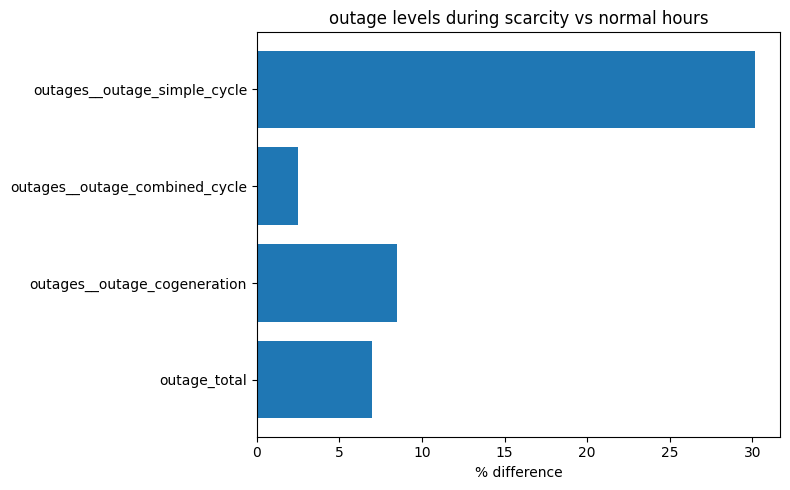

In [112]:
# create figure of size 8 by 5
plt.figure(figsize = (8,5))

# create bar graph plotting each outage type against their pct differences
plt.barh(
    outage_comparison.index,
    outage_comparison['pct_difference']
)

# labels
plt.xlabel('% difference')
plt.title('outage levels during scarcity vs normal hours')

plt.tight_layout()
plt.show()

#### Observations

##### Thermal availability declines during scarcity events

Aggregate thermal availability was approximately 300 MW lower during scarcity hours than during normal operating conditions.

This suggests that reduced dispatchable generation contributes meaningfully to system stress and reinforces the idea that scarcity is fundamentally driven by tightening supply-demand conditions.

##### Combined-cycle availability exhibits the highest decline

Combined-cycle availability fell by approximately 231 MW (-12%) during scarcity hours.

This was the largest availability difference among the thermal generation categories examined and indicates that combined-cycle resources play an important role in maintaining system flexibility.

The result contrasts with the earlier outage analysis, where combined-cycle outages appeared relatively unimportant. This suggests that generation availability may provide a more informative view of system conditions than outage volumes alone.

##### Simple-cycle resources remain relevant

Simple-cycle availability declined by approximately 53 MW (-7%) during scarcity hours.

While the magnitude is smaller than the combined-cycle result, the finding is consistent with earlier observations that simple-cycle outages are elevated during scarcity conditions.

Taken together, the results suggest that peaking resources contribute meaningful scarcity information through both outage and availability channels.

##### Cogeneration availability cahnges little between regimes

Cogeneration availability was nearly identical between scarcity and non-scarcity hours.

This mirrors the weak outage results observed earlier and suggests that cogeneration resources may play a comparatively limited role in explaining scarcity conditions.

##### Availability appears more informative than outages

The availability comparisons reveal larger and more intuitive differences between scarcity and non-scarcity conditions than the outage analysis alone.

This supports a broader conclusion emerging throughout the notebook: the market appears to respond more strongly to the amount of dispatchable generation available than to raw outage totals.

The results suggest that combined-cycle and simple-cycle resources may contribute to scarcity through different mechanisms. Combined-cycle generation appears to provide a large share of Alberta’s thermal supply, while simple-cycle units may play a more important role during stressed operating conditions. This interpretation is consistent with the stronger scarcity signal observed in simple-cycle outage and availability metrics despite the larger absolute availability changes observed for combined-cycle resources.

In [113]:
# create datafram for quantile distribution of thermal availability amounst scarcity and normal hours
pd.DataFrame({
    "scarcity": scarcity["thermal_availability"].quantile(
        [0.1,0.25,0.5,0.75,0.9]
    ),
    "normal": normal["thermal_availability"].quantile(
        [0.1,0.25,0.5,0.75,0.9]
    )
})

,scarcity,normal
0.10,4975.00,5041.6
0.25,5253.75,5294.0
0.50,5623.50,5750.0
0.75,6102.25,6335.0
0.90,6415.70,7601.0


#### Observations

##### Thermal availability distributions diverage at higher availability levels

The difference between scarcity and non-scarcity hours grows substantilly toward the upper end of ther thermal availability distribution. 

While median availability differes by on ly aobut 127 MW, the 90th percentile differs by more than 1,100 MW. 

This suggests that scarcity hours are characterized not only by lower average thermal availability, but also by the absence of exceptionally high-availability conditions.

In other words, scarcity tends to occur when the system loses access to its most comfortable supply states.

## Section 3

### Capacity Margin Analysis

Objective:

Evaluate whether scarcity is better explained by the relationship between available thermal generation and system demand than by either variable individually.

Method:

Construct two relative-capacity features:
- thermal_capacity_margin
- thermal_availability_pct

These variables combine thermal availability and net load into a single measure of system tightness.

Interpretation:

Absolute availability does not indicate whether the system is stressed because the operational significance of available generation depends on the amount of demand that must be served.

Relative-capacity measures explicitly account for this relationship and may therefore provide stronger scarcity signals than availability or net load alone.

In [114]:
# defining thermal capacity margin as thermal availability minus net load
df['thermal_capacity_margin'] = (
    df['thermal_availability'] - df['net_load']
)

In [115]:
# defining thermal availability pct as thermal availability / net load
df['thermal_availability_pct'] = (
    df['thermal_availability'] / df['net_load']
)

In [116]:
# running auc analysis on the thermal availiable pct and thermal capacity margin variables
print(feature_auc(df, 'thermal_availability_pct'))
print(feature_auc(df, 'thermal_capacity_margin'))

{'feature': 'thermal_availability_pct', 'auc': 0.7895291244086025, 'direction': 'negative', 'n_obs': 48929}
{'feature': 'thermal_capacity_margin', 'auc': 0.8128393299086845, 'direction': 'negative', 'n_obs': 48929}


#### Observations

##### Relative capacity measures outperform absolute availability

Earlier analysis showed that thermal availability alone contains only modest scarcity information. By combining availability with net load, both engineered features produced substantially stronger AUC values:

- thermal_availability_pct: 0.790
- thermal_capacity_margin: 0.813

Both features outperform net load alone (AUC = 0.780) and significantly outperform raw thermal availability.

##### Capacity margin is the strongest feature tested so far

Thermal capacity margin produced the highest AUC observed in the notebook.

This suggests that scarcity is better explained by the relationship between available thermal generation and system demand than by either variable individually.

The result is consistent with the physical reality of power markets. System operators and market participants are ultimately concerned with how much dispatchable capacity remains available after accounting for demand requirements.

##### Relative supply-demand balance appears more important than absolute capacity

A thermal availability value of 6,000 MW may represent a comfortable operating condition during periods of low demand but a stressed condition during periods of high demand.

By incorporating net load directly into the calculation, both thermal_availability_pct and thermal_capacity_margin provide a more realistic measure of system tightness.

##### Capacity margin slightly outperforms availability percentage

Although both engineered features performed well, thermal_capacity_margin produced the stronger result.

This may indicate that scarcity is more closely related to the absolute MW difference between available capacity and demand than to the percentage relationship between the two variables.

Further analysis using deciles and regime comparisons will help determine whether this relationship remains consistent across different operating conditions.

### Capacity State Analysis 

Objective:

Evaluate how scarcity risk changes when high net load and low thermal availability occur individually and simultaneously.

Method:

Classify each hour into one of four operating states:
- Neither condition
- High net load only
- Low thermal availability only
- Both conditions simultaneously

High net load is defined as the top 20% of net load hours.

Low thermal availability is defined as the bottom 20% of thermal availability hours.

For each state, calculate:
- number of observations
- scarcity frequency
- average pool price
- average thermal availability

Interpretation:

If scarcity is fundamentally driven by supply-demand imbalance, hours exhibiting both elevated net load and reduced thermal availability should experience the highest scarcity frequency and pool prices.

In [117]:
# define high net load at the upper 20% of net load hours
df["high_net_load"] = (
    df["net_load"] > df["net_load"].quantile(0.8)
)

# define low thermal availability as the bottom 20% of dispatchable thermal availability hours
df["low_thermal_availability"] = (
    df["thermal_availability"] < df["thermal_availability"].quantile(0.2)
)

In [118]:
# defining conditions for both, neither, and either-or
conditions = [
    (~df["high_net_load"]) & (~df["low_thermal_availability"]),
    (df["high_net_load"]) & (~df["low_thermal_availability"]),
    (~df["high_net_load"]) & (df["low_thermal_availability"]),
    (df["high_net_load"]) & (df["low_thermal_availability"]),
]

# assigning each condition a label
labels = [
    'Neither',
    'High net load',
    'Low availability',
    'Both'
]

# creat capacity state column selecting conditions, and corresponding labels
df['capacity_state'] = np.select(
    conditions,
    labels,
    default = 'unknown'
)


In [119]:
# groupby capacity state conditions 
capacity_state_summary = (
    # for each new dataframe calculate some summary statistics
    df.groupby('capacity_state').agg(
        # create n_hours column for size of scarcity events within each condition
        n_hours = ('scarcity_event', 'size'),
        # create scarcity rate mean for each condition
        scarcity_rates = ('scarcity_event', 'mean'),
        # create average price mean for each condition
        avg_price = ('price__ACTUAL_POOL_PRICE', 'mean'),
        # create mean thermal availability for each condition
        avg_thermal_availability = ('thermal_availability', 'mean'),    
    ).reindex(labels)
)

capacity_state_summary

,n_hours,scarcity_rates,avg_price,avg_thermal_availability
capacity_state,,,,
Neither,29839,0.031201,64.109747,6199.448105
High net load,9318,0.187487,179.315126,6356.978107
Low availability,9304,0.066101,99.167911,4990.859953
Both,468,0.339744,297.990748,5043.525641


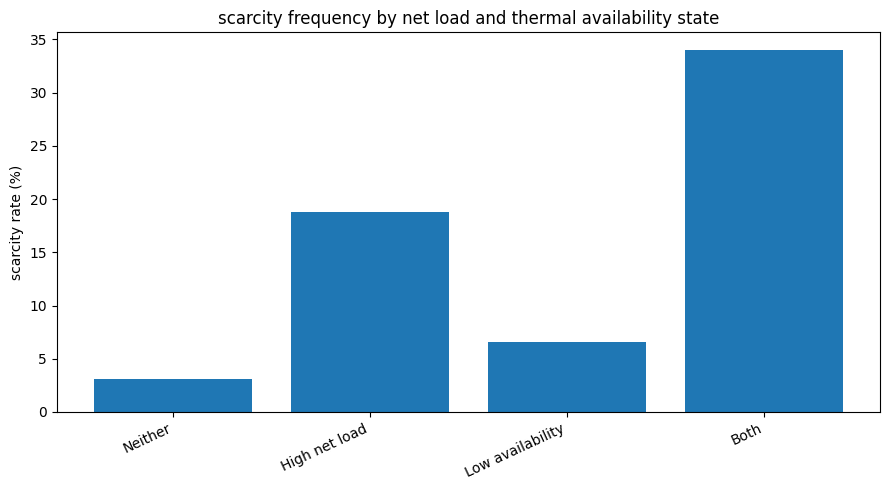

In [120]:
# create figure of size 9 by 5
plt.figure(figsize = (9,5))

# create bar graph with each condition and its corresponding scarcity rate as a pct
plt.bar(
    capacity_state_summary.index,
    capacity_state_summary['scarcity_rates'] * 100
)

# label and title
plt.ylabel('scarcity rate (%)')
plt.title('scarcity frequency by net load and thermal availability state')
plt.xticks(rotation = 25, ha = 'right')

plt.tight_layout()
plt.show()

#### Observations

##### High net load remains the dominant scarcity condition

Hours classified as high net load experienced scarcity nearly 19% of the time, compared to only 3% for hours where neither condition was present.

This result is consistent with the earlier AUC analysis and reinforces the conclusion that net load is the strongest individual scarcity driver.

##### Low thermal availability contributes additional risk

Hours with low thermal availability experienced scarcity approximately 6.6% of the time.

While the effect is smaller than high net load, the result suggests that reduced dispatchable generation still contributes meaningfully to system stress.

##### Scarcity risk is highest when both conditions occur simultaneously

Hours characterized by both elevated net load and reduced thermal availability experienced scarcity approximately 34% of the time.

This is the highest scarcity frequency observed among all operating states and indicates that supply-side and demand-side stress reinforce one another.

##### Pool prices respond similarly

Average pool prices increased from approximately $64/MWh during normal operating conditions to nearly $300/MWh when both conditions were present.

This suggests that the same system conditions associated with scarcity also correspond to substantially tighter market outcomes.

##### Supply-demand interactions appear more informative than individual variables

The results support a broader theme emerging throughout the notebook: scarcity is best understood as the interaction between available supply and system demand rather than either component in isolation.

This observation helps explain why thermal capacity margin outperformed both thermal availability and net load individually.

### Capacity Margin Decile Analysis

Objective:

Evaluate how scarcity risk changes across different levels of system tightness.

Method:

Convert both thermal_capacity_margin and thermal_availability_pct into deciles and calculate:
- scarcity frequency
- average pool price
- average capacity conditions

for each bucket.

Interpretation:

If capacity conditions are genuinely important drivers of scarcity, the lowest-capacity deciles should exhibit substantially higher scarcity frequencies and pool prices than the highest-capacity deciles.

Comparing thermal_capacity_margin and thermal_availability_pct also helps determine whether absolute MW shortfalls or percentage-based capacity measures provide better separation of scarcity risk.

In [121]:
df['thermal_availability_pct_decile'] = pd.qcut(
    df['thermal_availability_pct'], 10, labels = False, duplicates = 'drop'
)

margin_decile_summary = (
    df.groupby('thermal_availability_pct_decile').agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
        avg_thermal_availability_pct=("thermal_availability_pct", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
    )
)

margin_decile_summary


,n_hours,scarcity_rate,avg_thermal_availability_pct,avg_price
thermal_availability_pct_decile,,,,
0,4893,0.248110,0.536133,229.283211
1,4893,0.154506,0.575352,159.046199
2,4893,0.096260,0.600008,118.461662
3,4893,0.068261,0.621934,98.393002
4,4893,0.042305,0.644723,80.912062
5,4892,0.030458,0.671636,73.160382
6,4893,0.030247,0.708683,69.618132
7,4893,0.024525,0.767975,59.961142
8,4893,0.008788,0.870407,38.634137


In [122]:
# create thermal capacity margin deciles
# decile 0 = tightest margin hours
# decile 9 = most comfortable margin hours

df["thermal_capacity_margin_decile"] = pd.qcut(
    df["thermal_capacity_margin"],
    10,
    labels=False,
    duplicates="drop"
)

# calculate scarcity frequency and average price by margin decile
capacity_margin_decile_summary = (
    df.groupby("thermal_capacity_margin_decile")
      .agg(
          n_hours=("scarcity_event", "size"),
          scarcity_rate=("scarcity_event", "mean"),
          avg_margin=("thermal_capacity_margin", "mean"),
          avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
      )
)

capacity_margin_decile_summary

,n_hours,scarcity_rate,avg_margin,avg_price
thermal_capacity_margin_decile,,,,
0,4893,0.297159,-4677.509086,257.655105
1,4893,0.134069,-4050.277682,145.294139
2,4893,0.090946,-3675.584895,117.323372
3,4893,0.059268,-3362.590045,95.322203
4,4893,0.040670,-3066.843120,81.658007
5,4892,0.031889,-2751.267234,73.602150
6,4893,0.023299,-2375.519744,62.931202
7,4893,0.019007,-1864.096777,55.838586
8,4893,0.007153,-1030.191362,38.004210


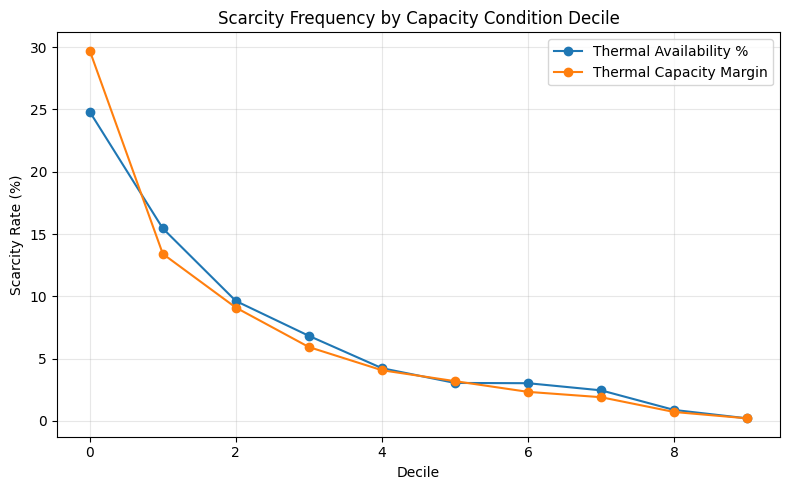

In [123]:
# compare both scarcity curves on the same chart
plt.figure(figsize=(8, 5))

plt.plot(
    margin_decile_summary.index,
    margin_decile_summary["scarcity_rate"] * 100,
    marker="o",
    label="Thermal Availability %"
)

plt.plot(
    capacity_margin_decile_summary.index,
    capacity_margin_decile_summary["scarcity_rate"] * 100,
    marker="o",
    label="Thermal Capacity Margin"
)

plt.xlabel("Decile")
plt.ylabel("Scarcity Rate (%)")
plt.title("Scarcity Frequency by Capacity Condition Decile")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Observations

##### Scarcity risk declines almost monotonically as capacity conditions improve

Both thermal_capacity_margin and thermal_availability_pct produced smooth, monotonic scarcity probability curves.

For thermal capacity margin:
- decile 0: 29.7% scarcity frequency
- decile 9: 0.2% scarcity frequency

For thermal availability percentage:
- decile 0: 24.8% scarcity frequency
- decile 9: 0.2% scarcity frequency

The consistency of these curves suggests that both metrics successfully capture the underlying supply-demand balance of the system.

##### Capacity margin produces the strongest separation in stressed conditions

Although the two curves are very similar overall, thermal capacity margin exhibits stronger scarcity concentration in the most constrained operating state.

The lowest capacity margin decile experiences scarcity nearly 30% of the time, compared to approximately 25% for the lowest thermal availability percentage decile.

This result is consistent with the earlier AUC analysis and suggests that absolute MW shortfalls contain slightly more scarcity information than percentage-based measures.

##### pool prices respond in the same direction as scarcity frequency

Average pool prices decline steadily as capacity conditions improve. 

For thermal capacity margin: 
- decile 0 average price: $258/MWh
- decile 9 average price: $ 22/MWh

The close alignment between scarcity frequency and average price provides additional confidence that these variables capture meaningful operational stress rather than statistical noise.

##### Capacity margin and availability percentage describe the same underlying phenomenon

The near-overlap of the two curves is an important result.

Although the metrics are constructed differently, both are built from the same underlying relationship between thermal availability and net load. The similarity of their behavior suggests that the core finding is robust and not dependent on a particular feature definition.

In practical terms, both metrics describe system tightness.

##### Thermal capacity margin emerges as the preferred capacity-state metric

Thermal capacity margin achieved the strongest AUC in the notebook and produced the highest scarcity concentration in the most constrained decile.

In addition, the metric is expressed directly in MW, making it easier to interpret operationally than a percentage ratio.

For these reasons, thermal capacity margin appears to be the most useful single measure of system tightness identified in the analysis and will serve as the primary capacity-state metric moving forward.

### Load and Availability Heatmap

In [124]:
# create load deciles in 10 buckets
df["load_decile"] = pd.qcut(
    df["net_load"],
    10,
    labels=False,
    duplicates="drop"
)

# define availability decile in 10 buckets
df["availability_decile"] = pd.qcut(
    df["thermal_availability_pct"],
    10,
    labels=False,
    duplicates="drop"
)

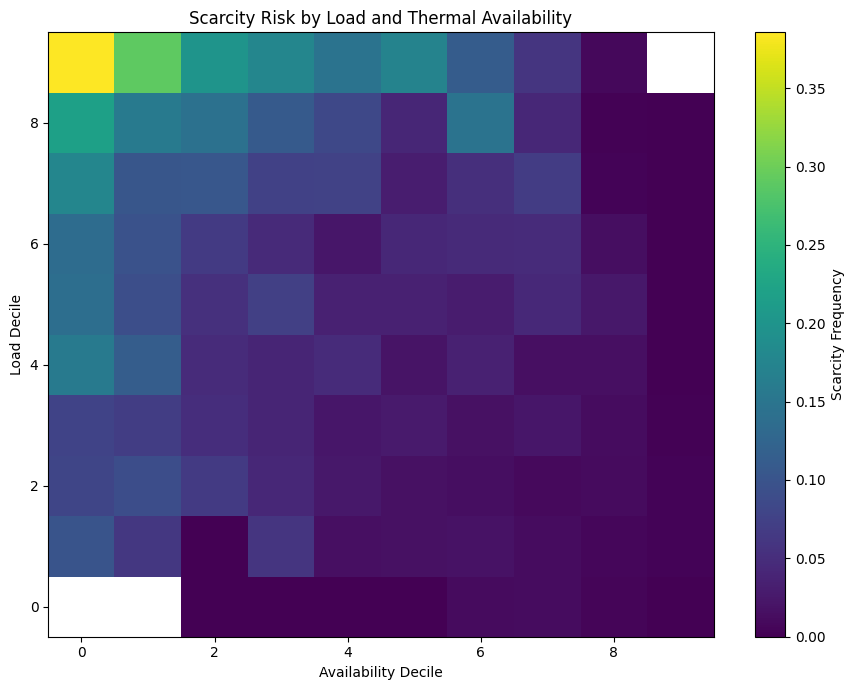

In [125]:
# create heatmap grouped by load and availability decile for scarcity events
heatmap_df = (
    df.groupby(
        ["load_decile", "availability_decile"]
    )["scarcity_event"]
    .mean()
    .unstack()
)

# create 9 by 7 figure
plt.figure(figsize=(9,7))

plt.imshow(
    heatmap_df, aspect="auto", origin="lower"
)

plt.colorbar(label="Scarcity Frequency")

# define x label, y label, and title
plt.xlabel("Availability Decile")
plt.ylabel("Load Decile")
plt.title("Scarcity Risk by Load and Thermal Availability")

plt.tight_layout()
plt.show()

In [140]:
# test AUC values for each year
for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    year_df = df[df['timestamp'].dt.year == year]
    result = feature_auc(year_df, 'thermal_capacity_margin')
    print(f"  {year}: {result['auc']:.3f}")

  2020: 0.931
  2021: 0.840
  2022: 0.798
  2023: 0.806
  2024: 0.875
  2025: 0.847


#### Observations

##### Scarcity risk increases as load rises and availability falls

The heatmap shows a clear transition from low scarcity frequencies in the upper-right corner (low load, high availability) to high scarcity frequencies in the lower-left corner (high load, low availability).

##### High load alone is not sufficient to create scarcity

Even within the highest load deciles, scarcity frequency remains relatively low when thermal availability is high. This suggests that elevated demand does not automatically produce scarcity if sufficient dispatchable generation remains available.

##### Availability becomes most important during stressed conditions

The largest scarcity frequencies occur when high load coincides with low availability. For example, the highest load decile combined with the lowest availability decile experienced scarcity rates approaching 40%.

##### The heatmap reinforces the capacity margin framework

These results support the earlier AUC and decile analyses. Scarcity is not driven solely by demand or supply conditions individually, but by the interaction between the two. This helps explain why thermal capacity margin emerged as the strongest feature tested in the notebook.

##### The capacity margin relationship appears structurally persistent

Additional validation showed that thermal capacity margin maintained strong predictive performance across every year examined:
- 2020: 0.931
- 2021: 0.840
- 2022: 0.798
- 2023: 0.806
- 2024: 0.875
- 2025: 0.847

This suggests that the relationship is not driven by a single weather regime, market event, or sample period. Instead, capacity margin appears to capture a persistent feature of Alberta market dynamics, providing additional confidence that system tightness is one of the primary drivers of scarcity conditions.

### Composite Stress Score Validation

Objective: 
Evaluate whether a composite system stress score provides stronger scarcity separation than its individual component variables. 

Method: 
Calculate ROC AUC using the stress_score_norm feature agaisnt the scarcity_event label. Compare the resulting AUC against the previously tested individual variables:
- net_load
- renewable_share
- gen_wind

The stress score combines:
- high net load
- low renewable share
- low wind generation

Interpretation:
- AUC = 0.50 → no separation
- AUC ≈ 0.60 → weak signal
- AUC ≈ 0.70 → useful signal
- AUC ≥ 0.80 → strong signal

If the composite score outperforms the individual features, it suggests that scarcity is driven by multiple interacting system conditions rather than a single operational variable. 

In [142]:
auc = roc_auc_score(
    df['scarcity_event'],
    df['stress_score_norm']
)

print(auc)

0.75323708512097


In [143]:
# creating new stress norm definitions. 
# one carries the reserve proxy feature, and the other does not. 
# well see if the roc_auc_score improves without reserve proxy.
stress_3 = (
    df['net_load_pct'] + df['low_renewable_pct'] + df['low_wind_pct']
)

stress_4 = (
    df['net_load_pct'] + df['low_renewable_pct'] + df['low_wind_pct'] + df['low_reserve_pct']
)

print(roc_auc_score(df['scarcity_event'], stress_3))
print(roc_auc_score(df['scarcity_event'], stress_4))

0.7532370946759253
0.7596980535995288


#### Observations

##### The composite stress score does not outperform net load

Unlike the earlier notebooks, the composite stress score did not outperform the strongest individual scarcity variable. The stress score produced an AUC of approximately 0.75-0.76, while net load alone achieved an AUC of 0.78. 

This suggests that combining multiple scarcity indicators does not automcatically create a stronger ranking variable. In this case, the strongest signal may already by captures by net laod itself. 

##### Net load already contains information from several stress score components

One possible explanation is that renewable generation is already embedded within the net load calculation: 

net load = demand - renewable generation

As a result, reneable share and wind genreation are not entirely independent sources of information. Adding them to the stress score may introduce variables that are partially describing the same underlying system conditino rather than contributing entirely new ifnormation. 

The result highlights the importance of considering feature overlap when constructing composite indicators. The features used to create the composite made physical sense, future composites defined by statistical optimization and machine learning discovery should be explored in future notebooks. 

##### Reserve conditions contribute incremental information

Although reserve_proxy_pxt was a relatively weak standalone feature, adding it to the composite score produced a small improvement: 
- 3-variable stress score: 0.753
- 4-variable stress score: 0.760

This suggests that reserve conditions contain some scarcity information that is not fully captures by net load, renewable share, and wind generation alone. 

The improvement is modest, but it demonstrates that variables with weak standalone performance can still contribute useful information when combined with other system-state indicators. 

##### The decline relative to earlier notebooks is likely driven by the dataset rebuild

The original stress score achieved stronger performance in the archived notebooks. However, direct comparisons should be interpreted cautiously because the underlying dataset has changed substantially.

The current dataset incorporates revised generation, outage, availability, and interchange data, along with a rebuilt feature engineering pipeline. As a result, changes in stress score performance may reflect improvements in data quality rather than changes in the underlying market relationships.

### Stress Score Decile Analysis

Objective:
Evaluate whether higher stress score values correspond to progressively higher scarcity probabilities. 

Method: Convert the continuous stress_score_norm variable into deciles using pd.qcut(), where: 
- decile 0 = lowest-stress 10% of hours
- decile 9 = highest-sttress 10% of hours

Calculate the average scarcity frequency within each decile. 

Interpretation: 

A useful stress score should produce increasing scarcity probabilites as stress increases. 

A monotonic relationship (higher deciles consistently producing higher scarcity frequencies) suggests that the score is successfully ranking system conditions from low risk to high risk. 

While ROC AUC measures ranking quality at the individual observation level, decile analysis evaluates the practical usefulness of the score as a risk classification tool. 

In [145]:
# convert continuous stress score into deciles
# decile 0 = least stressed 10% of hours
# decile 9 = most stressed...
df['stress_decile'] = pd.qcut(
    df['stress_score_norm'],
    q = 10,
    labels = False,
    duplicates = 'drop'
)

# groupby stress_decile for scarcity events
stress_decile_rates = (
    df.groupby("stress_decile")["scarcity_event"].mean()
)

# deciles for net load
df['net_load_decile'] = pd.qcut(
    df['net_load'],
    q=10,
    labels=False,
    duplicates='drop'
)

# groupby net_load_decile for scarcity event
netload_decile_rates = (
    df.groupby('net_load_decile')['scarcity_event'].mean()
)

# compare scarcity probabilities across identical deciles
# for both stress score and net load
decile_comparison = pd.DataFrame({
    'stress_score': stress_decile_rates,
    'net_load': netload_decile_rates
})

decile_comparison


,stress_score,net_load
0,0.007562,0.004701
1,0.016350,0.012671
2,0.024116,0.019620
3,0.030860,0.027182
4,0.042305,0.041283
5,0.056827,0.055192
6,0.066830,0.061925
7,0.101778,0.093399
8,0.148375,0.135704
9,0.210505,0.253832


#### Observations

##### The stress score provides additional context at moderate stress levels

Comparison against net-load deciles shows that the stress score produces slightly higher scarcity frequencies throughout most of the distribution.

This suggests that incorporating renewable and wind conditions helps identify differences in risk that are not fully captured by net load alone, particularly during low-to-moderate stress periods.

##### Net load remains strongest during extreme system conditions

In the highest decile, net load produced a scarcity frequency of approximately 25%, compared to 21% for the stress score.

This indicates that net load remains the dominant scarcity variable when the system approaches its most constrained operating conditions.

The result is consistent with the AUC analysis, where net load remained the strongest individual predictor.



## Section 4

### Simple-Cycle Outage Investigation

Objective:

Investigate whether simple-cycle outages are uniquely important during scarcity events.

Earlier sections showed that total outages were relatively weak predictors of scarcity, but simple-cycle outages appeared more informative than other outage categories. This section tests whether that signal persists across multiple views of the data.

Method:

Evaluate simple-cycle outages using:
- single-feature ROC AUC
- scarcity vs normal summary statistics
- outage decile analysis
- high-net-load subset comparison

Interpretation:

If simple-cycle outages matter operationally, scarcity frequency should increase when simple-cycle outages are elevated, especially during already-stressed system conditions.

This test helps determine whether simple-cycle outages are a meaningful scarcity driver or simply a secondary feature correlated with broader system stress.


In [127]:
# define high simple-cycle outage conditions
df["high_simple_cycle_outage"] = (
    df["outages__outage_simple_cycle"] > df["outages__outage_simple_cycle"].quantile(0.8)
)

In [128]:
# defining conditions for both, neither, and either-or
conditions = [
    (~df["high_net_load"]) & (~df["high_simple_cycle_outage"]),
    (df["high_net_load"]) & (~df["high_simple_cycle_outage"]),
    (~df["high_net_load"]) & (df["high_simple_cycle_outage"]),
    (df["high_net_load"]) & (df["high_simple_cycle_outage"]),
]

# assigning each condition a label
labels = [
    'Neither',
    'High net load',
    'Low availability',
    'Both'
]

# creat simple cycleoutage state column selecting conditions, and corresponding labels
df['simple_cycle_outage_state'] = np.select(
    conditions,
    labels,
    default = 'unknown'
)

# groupby simple cycle outage state conditions 
simple_cycle_outage_state_summary = (
    # for each new dataframe calculate some summary statistics
    df.groupby('simple_cycle_outage_state').agg(
        # create n_hours column for size of scarcity events within each condition
        n_hours = ('scarcity_event', 'size'),
        # create scarcity rate mean for each condition
        scarcity_rates = ('scarcity_event', 'mean'),
        # create average price mean for each condition
        avg_price = ('price__ACTUAL_POOL_PRICE', 'mean'),
        # create mean thermal availability for each condition
        avg_thermal_availability = ('thermal_availability', 'mean'),    
    ).reindex(labels)
)

simple_cycle_outage_state_summary

,n_hours,scarcity_rates,avg_price,avg_thermal_availability
simple_cycle_outage_state,,,,
Neither,30872,0.027436,63.234849,5968.765451
High net load,8283,0.171798,169.016431,6349.740674
Low availability,8271,0.084512,106.812082,5700.951034
Both,1503,0.321357,273.023892,5987.884232


In [129]:
# define high net load as net load above the 80th percentile
high_net_load = (
    df['net_load'] > df['net_load'].quantile(0.8)
)

# define simple cycle outage deciles as simple cycle outage data cut into 10 buckets
high_df['simple_cycle_outage_decile'] = pd.qcut(
    high_df['outages__outage_simple_cycle'],
    10,
    labels=False,
    duplicates='drop'
)


high_load_sc_summary = (
    # groupby simple cycle outage decile columns
    high_df.groupby('simple_cycle_outage_decile').agg(
        # number of scarcity hours per column
        n_hours=('scarcity_event','size'),
        # average scarcity rate per column
        scarcity_rate=('scarcity_event','mean'),
        # average outage value per column
        avg_outage=('outages__outage_simple_cycle','mean'),
        # average pool price per column
        avg_price=('price__ACTUAL_POOL_PRICE','mean')
    )
)

high_load_sc_summary

,n_hours,scarcity_rate,avg_outage,avg_price
simple_cycle_outage_decile,,,,
0,990,0.123232,86.441414,126.728889
1,989,0.078868,125.806876,104.655460
2,991,0.087790,157.122099,105.838244
3,959,0.166840,190.943691,172.831491
4,1002,0.132735,221.812375,152.045439
5,949,0.245522,250.300316,219.292329
6,971,0.205973,282.889804,200.322266
7,985,0.229442,371.147208,202.730305
8,992,0.383065,499.339718,312.853256


In [130]:
# define simple cycle's share of the net load
df['simple_cycle_share_of_load'] = (
    df['gen__gen_simple_cycle_system_available'] / df['net_load']
)

# run feature_auc on the simple cycle share of load variable
feature_auc(df, 'simple_cycle_share_of_load')

{'feature': 'simple_cycle_share_of_load',
 'auc': 0.7426765725819511,
 'direction': 'negative',
 'n_obs': 48929}

In [131]:
# create simple cycle share deciles out of simple cycle's share of the net load (10 buckets)
df['simple_cycle_share_decile'] = pd.qcut(
    df['simple_cycle_share_of_load'],
    10,
    labels=False,
    duplicates='drop'
)

sc_share_summary = (
    # groupby simple cycle share deciles
    df.groupby('simple_cycle_share_decile').agg(
        # calculate number of scarcity hours per decile
        n_hours=('scarcity_event','size'),
        # mean scarcity rate per decile column
        scarcity_rate=('scarcity_event','mean'),
        # mean share of load per decile column
        avg_share=('simple_cycle_share_of_load','mean'),
        # mean pool price per decile column
        avg_price=('price__ACTUAL_POOL_PRICE','mean')
      )
)

sc_share_summary

,n_hours,scarcity_rate,avg_share,avg_price
simple_cycle_share_decile,,,,
0,4893,0.225833,0.062193,208.827505
1,4893,0.126303,0.071116,137.005136
2,4893,0.078071,0.077186,98.663096
3,4893,0.063151,0.082768,86.694850
4,4893,0.085428,0.088557,103.554968
5,4892,0.050695,0.094225,82.494235
6,4893,0.029225,0.100186,72.176176
7,4893,0.019211,0.106362,64.489916
8,4893,0.014102,0.114413,54.755520


#### Observations

##### Simple-cycle outages appear most informative during already-stressed conditions

Earlier sections identified simple-cycle outages as one of the more informative outage-related variables in the dataset. However, outage magnitude alone produced inconsistent scarcity relationships when all hours were examined together.

This suggests that simple-cycle outages are not a universal scarcity driver and may instead depend on broader system conditions.

##### The relationship strengthens substantially during high net-load periods

When analysis is restricted to the highest 20% of net-load hours, scarcity frequency generally increases as simple-cycle outages rise.

This indicates that peaking-unit outages become more important when the system already requires large amounts of dispatchable generation. Under low-stress conditions, the system appears capable of absorbing many simple-cycle outages without experiencing scarcity.

##### High net load and elevated simple-cycle outages produce the highest scarcity frequencies

Hours characterized by both high net load and elevated simple-cycle outages experienced scarcity approximately 32% of the time.

This was substantially higher than either condition individually, suggesting that simple-cycle outages contribute most strongly when broader system stress is already present.

The result supports the view that peaking resources may function as an important layer of operational flexibility during tight system conditions.

##### Simple-cycle capacity relative to system demand contains meaningful scarcity information

Simple-cycle share of load produced a stronger signal than simple-cycle availability alone.

Scarcity frequency declined from approximately 23% in the lowest share-of-load decile to approximately 1% in the highest decile, indicating that scarcity becomes less likely when peaking resources represent a larger proportion of system requirements.

This suggests that the operational importance of simple-cycle generation depends not only on the amount of available peaking capacity, but also on the level of demand that capacity must support.

##### The underlying mechanism remains unclear

Although simple-cycle outages and simple-cycle share of load repeatedly emerged as useful scarcity indicators, the current dataset cannot fully explain why these relationships exist.

The analysis does not include information such as:
- ramp rates
- unit commitment decisions
- dispatch stack position
- operating reserve deployment
- real-time dispatch behaviour

As a result, simple-cycle variables should currently be viewed as informative scarcity indicators rather than fully understood causal drivers.

Future datasets containing commitment, dispatch, and flexibility-related information may provide a clearer explanation for the role of peaking resources during scarcity events.

## Section 5

### Regime Profiles

Objective: 

Characterize the operating conditions associated with scarcity events.

Method:

Compare scarcity and non-scarcity hours across:
- net load
- renewable share
- wind generation
- imports
- thermal availability
- thermal availability %
- thermal capacity margin
- outages

Then examine:
- distribution differences
- load/availability interaction heatmaps

Interpretation: 

Rather than identifying new predictors, this section summarizes what scarcity conditions actually look like operationally.

In [132]:
# defining regime profile features
profile_features = [
    'net_load',
    'renewable_share', 
    'gen_wind', 
    'total_imports',
    'outage_total',
    'thermal_availability',
    'thermal_capacity_margin',
    'thermal_availability_pct',
]

In [133]:
# defining scarcity and normal hours
scarcity = df[df["scarcity_event"] == 1]
normal = df[df["scarcity_event"] == 0]

# profile is data frame of each profile feature mean for scarcity and normal columns
profile = pd.DataFrame({
    "scarcity": scarcity[profile_features].mean(),
    "normal": normal[profile_features].mean()
})

# define difference columns
profile["difference"] = (
    profile["scarcity"] - profile["normal"]
)

# define pct difference column
profile["pct_difference"] = (
    profile["difference"] / profile["normal"] * 100
)

# sort values highest to lowest
profile.sort_values(
    "pct_difference", ascending=False
)

,scarcity,normal,difference,pct_difference
thermal_capacity_margin,-3997.164941,-2530.632724,-1466.532217,57.951207
total_imports,474.851101,316.705565,158.145535,49.934562
net_load,9708.681163,8540.238261,1168.442903,13.681619
outage_total,3649.678737,3548.853696,100.825041,2.841059
thermal_availability,5711.516222,6009.605537,-298.089314,-4.960214
thermal_availability_pct,0.591863,0.716613,-0.124750,-17.408331
renewable_share,0.127601,0.202670,-0.075069,-37.040237
gen_wind,578.613591,1071.186489,-492.572897,-45.983860


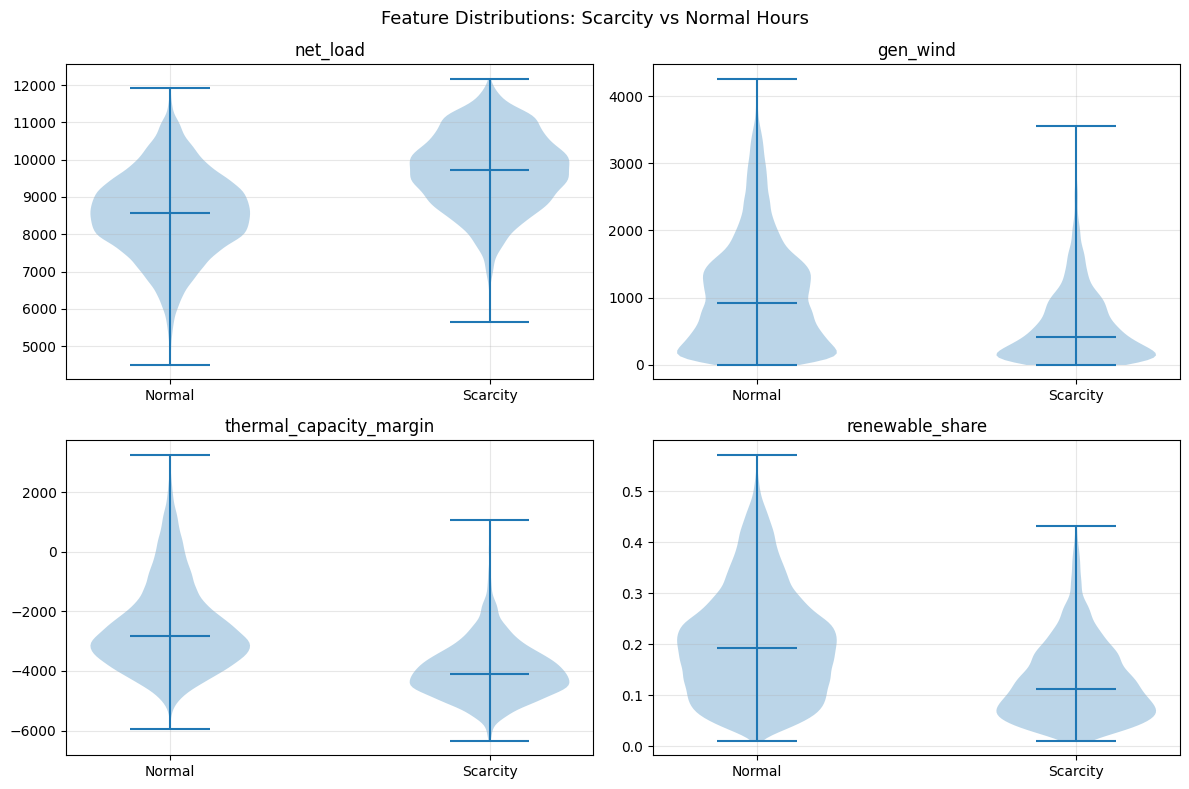

In [135]:
# create violin chart for major features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_features = ['net_load', 'gen_wind', 'thermal_capacity_margin', 'renewable_share']

for ax, feature in zip(axes.flatten(), plot_features):
    scarcity_vals = scarcity[feature].dropna()
    normal_vals = normal[feature].dropna()

    ax.violinplot(
        [normal_vals, scarcity_vals],
        positions=[0, 1],
        showmedians=True
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal', 'Scarcity'])
    ax.set_title(feature)
    ax.grid(True, alpha=0.3)

plt.suptitle("Feature Distributions: Scarcity vs Normal Hours", fontsize=13)
plt.tight_layout()
plt.show()

#### Observations

##### Scarcity hours exhibit a distinct operating profile

Compared to normal hours, scarcity events are characterized by higher net load, lower renewable production, lower wind generation, reduced thermal availability, and substantially tighter capacity margins.

These relationships remained consistent across both average-value comparisons and distributional analysis.

##### Renewable conditions differ more than outage conditions

Wind generation and renewable share were materially lower during scarcity events across nearly the entire distribution.

In contrast, total outage levels differed only modestly between scarcity and normal hours, reinforcing earlier findings that outages alone are insufficient to explain scarcity risk.

##### Imports increase during scarcity events

Scarcity hours exhibited substantially higher import levels than normal hours.

This suggests that interties respond to tightening system conditions, although the analysis cannot determine whether imports are acting as a leading indicator or a real-time response to emerging scarcity.

##### Capacity margin provides the clearest summary of system stress

Many of the individual scarcity characteristics identified throughout the notebook ultimately converge in thermal capacity margin.

Higher demand, lower renewable production, reduced availability, and tighter operating conditions all contribute to lower margins, helping explain why capacity margin emerged as the strongest scarcity variable tested.

##### Summary

The central finding of this notebook is that thermal capacity margin is the strongest scarcity variable tested.

Thermal capacity margin achieved an overall AUC of 0.813, outperforming net load, renewable share, wind generation, imports, outages, and raw availability measures. The relationship also remained strong across individual years, suggesting that capacity margin captures a persistent feature of Alberta market structure rather than a single-year artifact.

The broader interpretation is that scarcity is best understood as a tightening supply-demand balance problem. High net load matters, but scarcity risk rises most sharply when elevated demand coincides with reduced available thermal capacity and weaker renewable output.

Outages, imports, and simple-cycle availability remain useful secondary indicators, but they appear most meaningful when interpreted within the broader capacity margin framework.